In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

In [3]:
# Data

#FILEPATH = '.\\omicidi italia 2000-2024.xlsx'
FILEPATH = '.\\omicidi IT_ES_SW.xlsx'
df = pd.read_excel(FILEPATH, header=0)

df_IT = df[df['Code']=='ITA']
df_ES = df[df['Code']=='ESP']
df_SW = df[df['Code']=='SWE']

In [4]:
# Andamento temporale - femminicidi

x_data = df_IT['Year']
y_data = df_IT['Number of homicides - Female']
x_labels = [2000, 2005, 2010, 2015, 2020, 2022]


# statsmodels OLS:
# statistical method for estimating the parameters of a linear regression model
x = sm.add_constant(x_data) 
model = sm.OLS(y_data, x).fit()
print(model.summary())
predictions = model.get_prediction(x)
summary_frame = predictions.summary_frame(alpha=0.05)


# Estrai valori predetti e intervalli
y_pred = summary_frame['mean']
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']


                                 OLS Regression Results                                 
Dep. Variable:     Number of homicides - Female   R-squared:                       0.700
Model:                                      OLS   Adj. R-squared:                  0.687
Method:                           Least Squares   F-statistic:                     53.78
Date:                          Wed, 30 Apr 2025   Prob (F-statistic):           1.85e-07
Time:                                  17:41:33   Log-Likelihood:                -101.04
No. Observations:                            25   AIC:                             206.1
Df Residuals:                                23   BIC:                             208.5
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

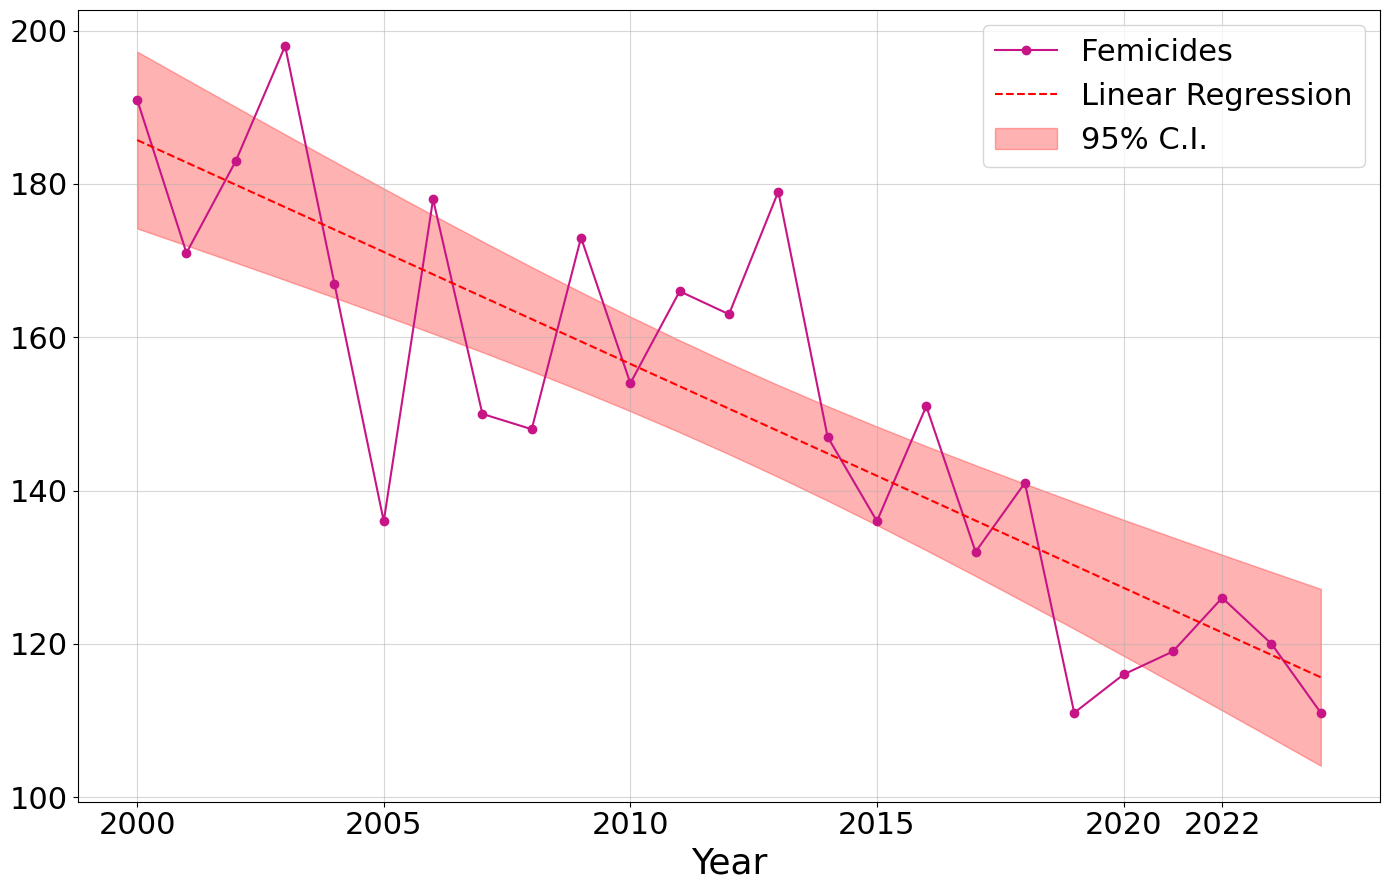

In [5]:
# Grafico
plt.figure(figsize=(14, 9))
plt.plot(x_data, y_data, marker='o', linestyle='-', color='mediumvioletred', label='Femicides')
# Linea di regressione
plt.plot(x_data, y_pred, color='red', linestyle='--', label='Linear Regression')
# CI
plt.fill_between(x_data, ci_lower, ci_upper, color='red', alpha=0.3, label='95% C.I.')

plt.xlabel('Year', fontsize=26)
#plt.ylabel('Femicides', fontsize=26)
plt.grid(True, alpha=0.5)
plt.xticks(x_labels, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()

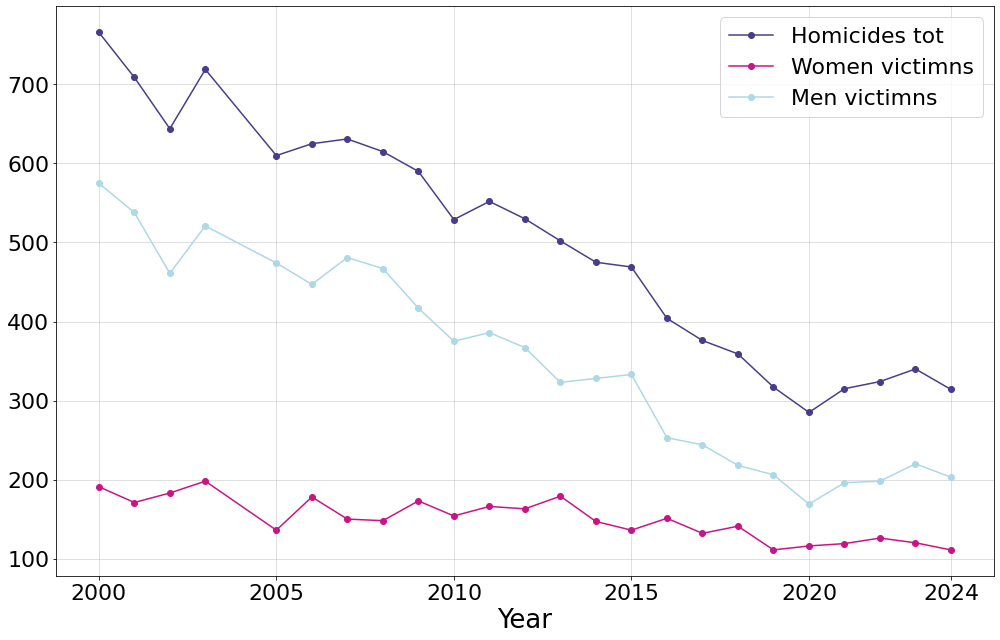

In [57]:
# Andamento temporale - femminicidi

x_data = df['Year']
y_data = df['Number of total homicides']
y_data_F = df['Number of female homicides']
y_data_M = df['Number of male homicides']
x_labels = [2000, 2005, 2010, 2015, 2020, 2024]

plt.figure(figsize=(14, 9))
plt.plot(x_data, y_data, marker='o', linestyle='-', color='darkslateblue', label='Homicides tot')
plt.plot(x_data, y_data_F, marker='o', linestyle='-', color='mediumvioletred', label='Women victimns')
plt.plot(x_data, y_data_M, marker='o', linestyle='-', color='lightblue', label='Men victimns')

plt.xlabel('Year', fontsize=26)

plt.grid(True, alpha=0.5)
plt.xticks(x_labels, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()

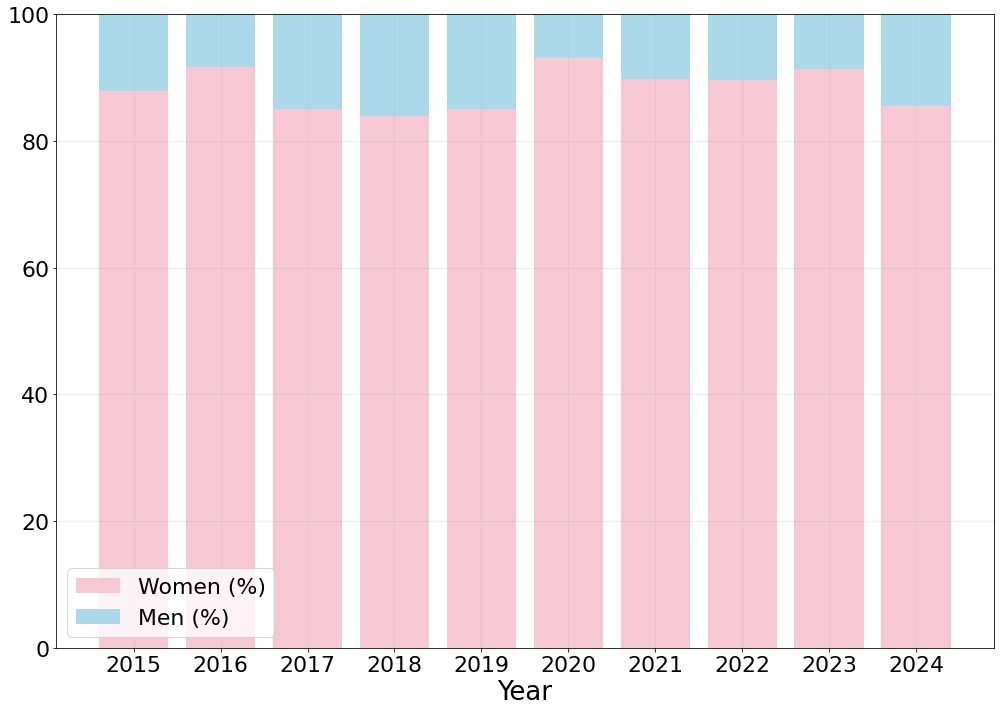

In [86]:
# Andamento temporale - by partners, in percentuale rispetto al totale di omicidi commessi da partner

df_copy = df[14:]
x_data = df_copy['Year']
tot = df_copy['Homicides (M+F) by Partner']
y_data_F = df_copy['Homicides (F) by Partner']
y_data_M = tot - y_data_F

percent_F = y_data_F / tot * 100
percent_M = y_data_M / tot * 100
colors=['#F6C8D3', '#ACD9E9']

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(x_data, percent_F, label='Women (%)', color='#F6C8D3')
ax.bar(x_data, percent_M, bottom=percent_F, label='Men (%)', color='#ACD9E9')

plt.xlabel('Year', fontsize=26)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.xticks(x_data, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()

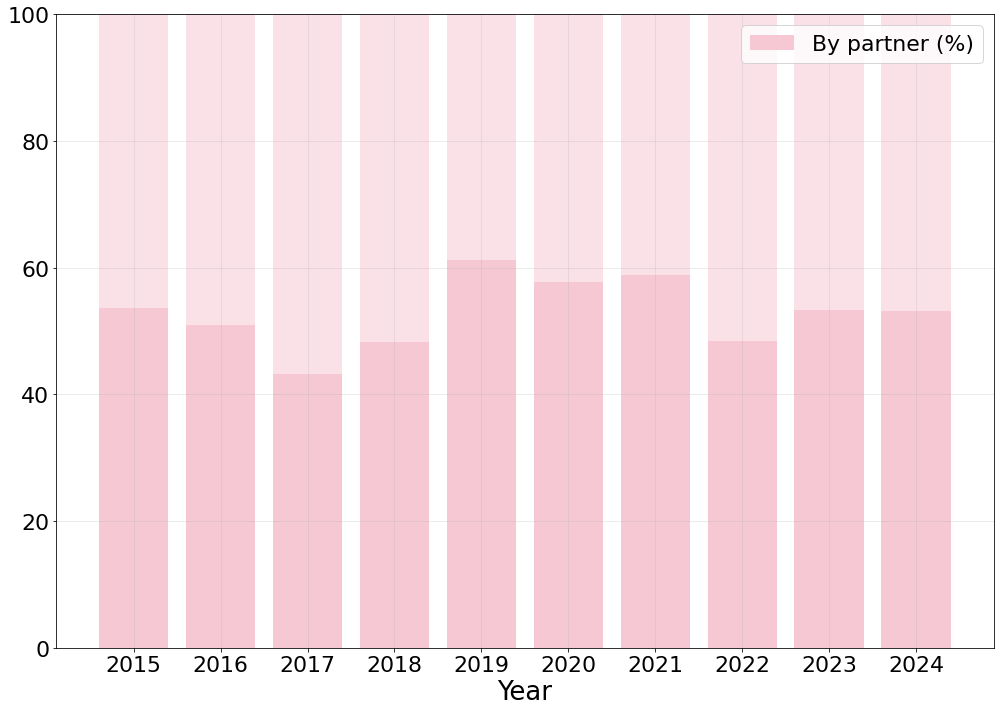

In [6]:
# Andamento temporale - femminicidi da partner, rispetto al tot di femminicidi
# dati riportati in %, rispetto al num tot di femminicidi

df_copy = df[14:]
x_data = df_copy['Year']
tot_F = df_copy['Number of female homicides']
by_partner_F = df_copy['Homicides (F) by Partner']

percent_F_partner = by_partner_F / tot_F * 100
percent_2 = 100 - percent_F_partner

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(x_data, percent_F_partner, label='By partner (%)', color='#F6C8D3')
ax.bar(x_data, percent_2, bottom=percent_F_partner, color='#FAE0E7')

plt.xlabel('Year', fontsize=26)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.xticks(x_data, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()

c:\Users\delia\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)
c:\Users\delia\anaconda3\lib\site-packages\scipy\stats\stats.py:1541: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                 -0.070
Method:                 Least Squares   F-statistic:                    0.4135
Date:                Mon, 14 Apr 2025   Prob (F-statistic):              0.538
Time:                        19:33:40   Log-Likelihood:                -30.407
No. Observations:                  10   AIC:                             64.81
Df Residuals:                       8   BIC:                             65.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -756.2805   1258.392     -0.601      0.5

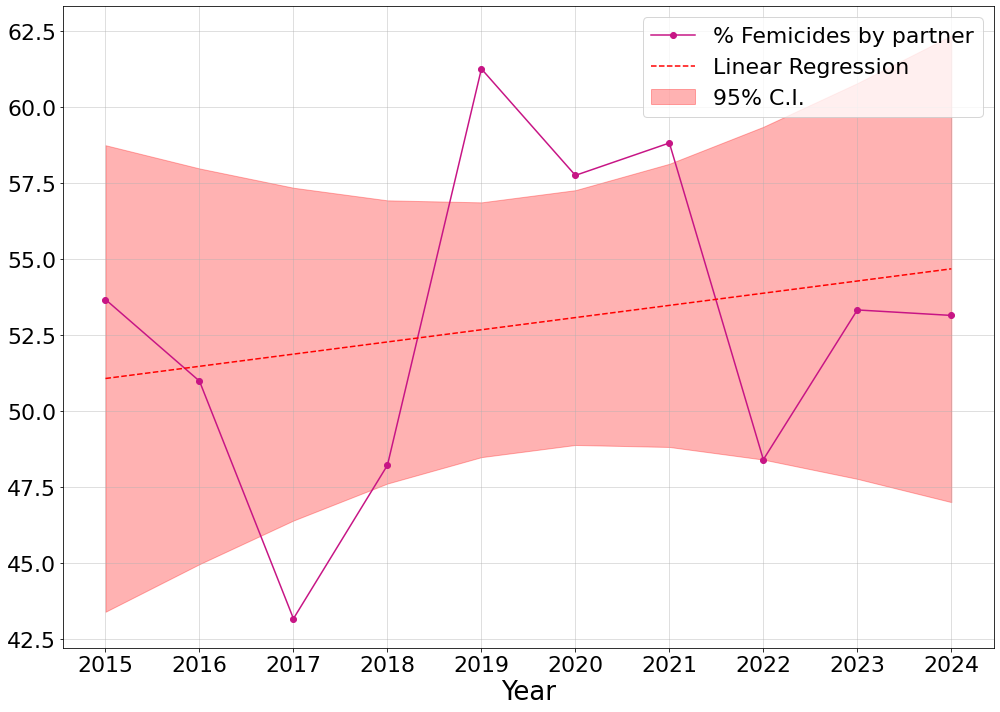

In [10]:
# Andamento temporale - femminicidi by partner

df_copy = df[14:]

x_data = df_copy['Year']
#y_data = df_copy['Homicides (F) by Partner']
#x_labels = [2000, 2005, 2010, 2015, 2020, 2024]
y_data = percent_F_partner


# Regressione lineare con statsmodels
x = sm.add_constant(x_data)  # Aggiunge l'intercetta (colonna di 1)
model = sm.OLS(y_data, x).fit()
print(model.summary())
predictions = model.get_prediction(x)
summary_frame = predictions.summary_frame(alpha=0.05)
# Estrai valori predetti e intervalli
y_pred = summary_frame['mean']
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']



# Grafico
plt.figure(figsize=(14, 10))

plt.plot(x_data, y_data, marker='o', linestyle='-', color='mediumvioletred', label='% Femicides by partner')

# Linea di regressione
plt.plot(x_data, y_pred, color='red', linestyle='--', label='Linear Regression')
# CI
plt.fill_between(x_data, ci_lower, ci_upper, color='red', alpha=0.3, label='95% C.I.')


plt.xlabel('Year', fontsize=26)
#plt.ylabel('Femicides', fontsize=26)

plt.grid(True, alpha=0.5)
plt.xticks(x_data, fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()